# 📐 Interactive 2D Projections with Linear Algebra
Welcome to this interactive notebook!
## Objective:
In this lesson, we'll see the use of Matrices. We will explore how matrix multiplication can be used to perform geometric transformations—specifically, projecting a 2D shape onto different axes.

## Use in Generative AI, ML
The projections are used to by non-supervised learning algorithms to differentiate beween data, based on its _features_ (_axes_ or _dimensions_). In real life, every data has some meaning or context, but human eyes often fail to capture the context behind the huge expanse of data. However, the ML algorithms like, *Support Vector Machine* (or SVM) use the projections of the data, taken at different angles, to understand how to differentiate parts of data from another.

For example, in this lesson, the data represents two houses (not one). The projection (shadows) of the two houses taken on the X-Axis does not provide much information (as they overlap). But, when projected (shadow) on the Y-axis, there is a clear demarcation in the shadows on Y-Axis.

### Step 1: Defining the Data
Before we can project anything, we need a shape. We represent a 2D shape as a collection of coordinate points.

* We define `house`, an $N \times 2$ matrix where each row is an $[x, y]$ coordinate.
* We then create a second house (`house2`), **translate** it by adding values to the X and Y coordinates, and concatenate them together to make a small neighborhood.
* **Crucial Step:** Notice the `np.transpose(house)` at the end. We must convert our data from an $N \times 2$ matrix into a $2 \times N$ matrix. In linear algebra, to cleanly apply a $2 \times 2$ transformation matrix to a set of points, the points must be represented as column vectors!

In [8]:
# =================================================================
# 2D PROJECTION DEMONSTRATION
# Run this cell in your Jupyter Notebook
# =================================================================

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Dropdown, IntSlider

# 1. Define a 2xN matrix representing points of a 2D figure (A House)
# Row 0: X coordinates, Row 1: Y coordinates
# house = np.matrix([
#     [1, 1.0, 1.0, 1.0, 1.0, 1, 0.5, 2.0, 3.5, 3, 3, 2, 1],  # X coords
#     [1, 1.2, 1.4, 1.8, 2.0, 3, 2.8, 3.5, 2.8, 3, 1, 1, 1]   # Y coords (drawn to trace the outline)
# ])
house = np.matrix(
[
    #Left corner
 [1.0, 1.0],
    #Left wall
 [1.0, 1.2],
 [1.0, 1.4],
 [1.0, 1.6],
 [1.0, 1.8],
 [1.0, 2.0],
 [1.0, 2.2],
 [1.0, 2.4],
 [1.0, 2.6],
 [1.0, 2.8],
 [1.0, 3.0],
    # Left slope
 [0.5, 2.8],
    [0.75, 2.9],
 [1.5, 3.25],
    #Peak, top
 [2.0, 3.5],



 #Right slope
 [2.37, 3.35],
 [2.75, 3.2],
 [3.0, 3.0],
 [3.25, 2.9],
 [3.5, 2.8],

 #Right wall
 [3.0, 2.8],
 [3.0, 2.6],
 [3.0, 2.4],
 [3.0, 2.2],
 [3.0, 2.0],
 [3.0, 1.8],
 [3.0, 1.6],
 [3.0, 1.4],
 [3.0, 1.2],
 [3.0, 1.0],

    #base
 [2.8, 1.0],
 [2.6, 1.0],
 [2.4, 1.0],
 [2.2, 1.0],
 [2.0, 1.0],
 [1.8, 1.0],
 [1.6, 1.0],
 [1.4, 1.0],
 [1.2, 1.0],
 [1.0, 1.0],
])

house2 = np.matrix(house)


# shift coordinates (translate)
house[:,0] += 2
house[:,1] += 6

house = np.concatenate((house, house2), axis=0)

print(house.shape)
print("Fifteenth coordinate [x,y]", house[14, :])
print(f"First {house[:14, :].shape[0]} " \
      f"coordinates \n[ [xi, yi],... ]: \n {house[:14, :]}")
house = np.transpose(house)
print()
print(house[:,:14])




(80, 2)
Fifteenth coordinate [x,y] [[4.  9.5]]
First 14 coordinates 
[ [xi, yi],... ]: 
 [[3.   7.  ]
 [3.   7.2 ]
 [3.   7.4 ]
 [3.   7.6 ]
 [3.   7.8 ]
 [3.   8.  ]
 [3.   8.2 ]
 [3.   8.4 ]
 [3.   8.6 ]
 [3.   8.8 ]
 [3.   9.  ]
 [2.5  8.8 ]
 [2.75 8.9 ]
 [3.5  9.25]]

[[3.   3.   3.   3.   3.   3.   3.   3.   3.   3.   3.   2.5  2.75 3.5 ]
 [7.   7.2  7.4  7.6  7.8  8.   8.2  8.4  8.6  8.8  9.   8.8  8.9  9.25]]


---
### Step 2: Visualizing the Original Data
To ensure our data represents what we think it does, we'll plot it using `matplotlib.pyplot`.

Notice how we use NumPy slicing for the `plt.plot()` function: 
* `data[0, :]` grabs the entire first row (all our X coordinates).
* `data[1, :]` grabs the entire second row (all our Y coordinates).

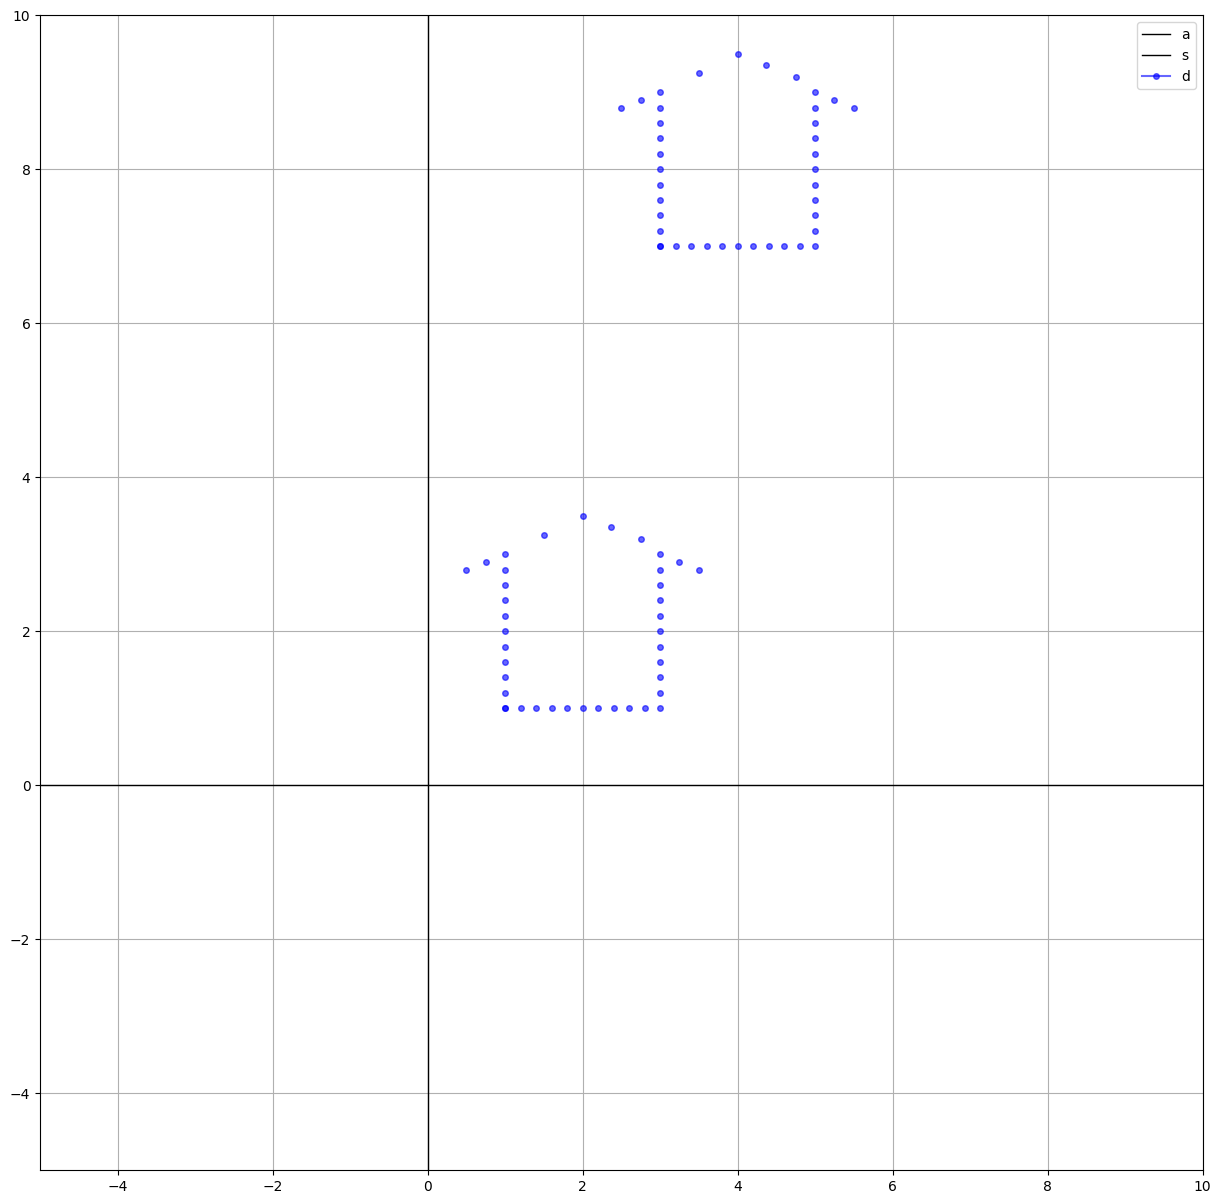

In [9]:
# Scatter Plot the data, using matplotlib library.
def plot2D(data: np.matrix):
    # Setup the plot
    #fig, ax = plt.subplots(figsize=(10, 5))

    plt.figure(figsize=(15, 15))
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)

    # Plot Original Figure (Blue)
    plt.plot(data[0, :], data[1, :], 'bo-',
             label='Original', markersize=4, alpha=0.6)
    plt.xlim(-5, 10)
    plt.ylim(-5, 10)
    plt.grid(True)
    plt.legend("asd")
    #plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

plot2D(house)

---
### Step 3: The Projection Matrices and Transformations
Here is where the linear algebra comes to life. A **projection matrix** (a type of square matrix) mathematically "collapses" our 2D points onto a 1D line. That is,
   **$$M^{Projected}_{D \times N} = P_{D \times D} \times M_{D \times N}$$**


where **P** is a projection square-matrix (a $2 \times 2$ matrix in this case, being _2-dimensional_ , or with $D=2$), when multiplied with the data-matrix **M** which represents the data-set (a matrix of N data-points of $dimension =D$, each of form $\begin{bmatrix} x_{i} \\ y_{i} \end{bmatrix}$) causes the data-set to shrink and form the shadow (projection) represented by **$M^{Projected}_{D \times N}$** on the given Axis, or Line, or a plane.


* **X-Axis Projection:** Keeps X, drops Y. $$P_{X} = \begin{bmatrix}
1 0 \\
0 0 \end{bmatrix}$$
* **Y-Axis Projection:** Keeps Y, drops X. $$P_{Y} = \begin{bmatrix}
0 0 \\
0 1 \end{bmatrix}$$
* **Custom Angle Projection:** Projects onto an arbitrary line passing through the origin at an angle $\theta$. The matrix for this is derived using trigonometry:
$$P(\theta) = \begin{bmatrix} \cos^2\theta & \cos\theta\sin\theta \\ \cos\theta\sin\theta & \sin^2\theta \end{bmatrix}$$

We apply this transformation using the `@` operator in Python, which is shorthand for `np.matmul()` (matrix multiplication): `P @ house`.

In [10]:

# 2. Define Projection Matrices
def get_projection_matrix(proj_type, angle_deg=45):
    if proj_type == "X-Axis":
        return np.array([[1, 0],
                         [0, 0]])
    elif proj_type == "Y-Axis":
        return np.array([[0, 0],
                         [0, 1]])
    elif proj_type == "Line y=x":
        return np.array([[0.5, 0.5],
                         [0.5, 0.5]])
    elif proj_type == "Custom Angle":
        # Projection matrix onto a line with angle theta
        theta = np.radians(angle_deg)
        c, s = np.cos(theta), np.sin(theta)
        return np.array([[c**2, c*s],
                         [c*s, s**2]])

# 3. Plotting and Operation Function
def plot_2d_projection(proj_type, custom_angle):
    # Get the selected projection matrix
    P = get_projection_matrix(proj_type, custom_angle)

    # Perform matrix multiplication: P @ House
    projected_house = P @ house

    # Setup the plot
    plt.figure(figsize=(8, 8))
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)

    # Plot Original Figure (Blue)
    plt.plot(house[0, :], house[1, :], 'bo-', label='Original', markersize=6, alpha=0.6)

    # Plot Projected Figure (Red)
    plt.plot(projected_house[0, :], projected_house[1, :], 'ro-', label='Projected', markersize=3)

    # Draw projection lines (dashed) showing where points moved
    for i in range(house.shape[1]):
        plt.plot([house[0, i], projected_house[0, i]],
                 [house[1, i], projected_house[1, i]], 'k--', alpha=0.3)

    # print(f"\nPROJECTION MATRIX: \n{P}")
    # print(f"\nPROJECTION MATRIX X HOUSE(DATA) \n{P} X \n{house[:, :14]}...")
    # print(f"\nPROJECTED HOUSE \n{projected_house[:, :14]}")
    plt.title(f"2D Projection: {proj_type}\nMatrix:\n{np.round(P, 2)}")
    plt.xlim(-5, 10)
    plt.ylim(-5, 10)
    plt.grid(True)
    #plt.legend()
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()


---
### Step 4: Making it Interactive
Now we will use the `ipywidgets` library to create a user interface directly inside the notebook. 

By wrapping our plotting function in the `interact()` method and passing it a `Dropdown` and `FloatSlider`, Jupyter will automatically re-run the plot and matrix multiplications every time you change a setting!

In [11]:
# Create interactive widgets
print("To use 'Angle', choos 'Custom Angle' from the drop-down!")
res = interact(plot_2d_projection,
         proj_type=Dropdown(options=["X-Axis", "Y-Axis", "Line y=x", "Custom Angle"], value="X-Axis"),

         custom_angle=FloatSlider(value=30, min=0, max=180, step=5, description="Angle (deg):"))


To use 'Angle', choos 'Custom Angle' from the drop-down!


interactive(children=(Dropdown(description='proj_type', options=('X-Axis', 'Y-Axis', 'Line y=x', 'Custom Angle…

---
### Bonus Step: How `interact` Works (A Sandbox)
If the main code block above feels complex, here is a bare-bones example of how `ipywidgets` links UI elements to a function.

Notice how the `IntSlider` seamlessly maps to the integer argument `w0`, and the `FloatSlider` maps to the float argument `w1`. Play with the sliders below to see the print statement update in real-time.

In [ ]:
def test_method(w0: int, w1: float):
    print(f"w0: {w0}, w1: {w1}")

interact(test_method,
         w0=IntSlider(min=0, max=55, step=1, value=5),
         w1=FloatSlider(min=-5, max=20, step=1, value=1))